# Part 2 – Air Quality: 03 Statistics, EDA & Visualisation

## Comprehensive Module Overview

Welcome to the **Analytical Layer** of our data pipeline. This notebook consumes the cleaned, curated Parquet dataset produced in `02_clean_features.ipynb` and applies robust statistical and visual techniques to interpret the data.

---
## Technical Approach & Tooling

We intentionally utilize a dual-engine analytical approach integrating both **Pandas** and **DuckDB**.
- **Pandas** provides the foundation for in-memory subsetting, rolling window calculations (via `.rolling()`), and tight integration with visualization libraries (Matplotlib/Seaborn).
- **DuckDB** is an extremely fast in-process analytical SQL database. By using DuckDB, we demonstrate how traditional SQL queries can be seamlessly woven into Python notebooks to perform complex `GROUP BY` rollups and Window Functions. We frequently cross-check `DuckDB` query results against `Pandas` DataFrame operations to validate analytical fidelity.

## Notebook Structure
- **Section A**: Group-by metrics (testing spatial and categorical variances).
- **Section B**: Window-based time-series metrics (testing temporal variances).
- **Section C**: Correlational & Extrema Analysis (testing meteorological relationships).
- **Section D**: Data Visualisation.


## Environment Initialization

We import `pandas`, `duckdb`, `matplotlib.pyplot`, and `seaborn`. We establish a global `CITIES_ORDERED` list and a `PALETTE` dictionary. Binding colors to specific cities early ensures that whether we generate a scatter plot or a line chart, LA will always be orange and NYC will always be green, preserving visual continuity across the report.

We read the binary Parquet file directly. The `date` column is automatically parsed as a fast `datetime64[ns]` object, eliminating the need to use `pd.to_datetime()` on string data.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import duckdb
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
})
PALETTE = {'New York City': '#1f77b4', 'Los Angeles': '#d62728', 'Chicago': '#2ca02c'}
CITIES_ORDERED = ['New York City', 'Chicago', 'Los Angeles']

ROOT    = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'part2_airquality' else Path(os.getcwd())
PARQUET = ROOT / 'data' / 'curated' / 'part2_airquality_curated.parquet'
FIG_DIR = ROOT / 'part2_airquality' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet(PARQUET)
df['date'] = pd.to_datetime(df['date'])

print(f'Shape : {df.shape}')
print(f'Period: {df.date.min().date()} -> {df.date.max().date()}')
print(f'Cities: {sorted(df.city.unique())}')
df.head()

Shape : (270, 9)
Period: 2025-01-01 -> 2025-03-31
Cities: ['Chicago', 'Los Angeles', 'New York City']


,city,date,pm25_mean,pm25_p90,temp_mean,wind_speed_mean,precip_sum,weekday,is_weekend
0,Chicago,2025-01-01 00:00:00+00:00,4.9417,6.6987,-0.0500,17.0000,0.3,Wednesday,0
1,Chicago,2025-01-02 00:00:00+00:00,4.6583,5.9396,-2.7292,17.0333,0.0,Thursday,0
2,Chicago,2025-01-03 00:00:00+00:00,5.7250,7.7504,-3.0250,14.0042,0.2,Friday,0
3,Chicago,2025-01-04 00:00:00+00:00,3.6625,4.2970,-7.5292,16.1167,0.0,Saturday,1
4,Chicago,2025-01-05 00:00:00+00:00,3.4417,4.3617,-7.3333,9.4750,0.0,Sunday,1


---
# Section A – Analytical Group-By Metrics

In this section, we slice the dataset across categorical dimensions (`city`, `is_weekend`, `weekday`) to extract macroscopic summary statistics.


## A1. Central Tendency & Dispersion: `pm25_mean`

We begin by characterizing the distribution of daily PM2.5 for each city.
- **DuckDB Approach**: We define a multi-line SQL string `q_a1` utilizing aggregate functions `AVG()`, `MEDIAN()`, and `STDDEV()`. `con.execute().df()` instantly compiles and executes the query against our local Pandas DataFrame, returning the result as a new DataFrame.
- **Pandas Cross-Check**: We use `df.groupby('city')['pm25_mean'].agg(['mean', 'median', 'std'])` to perform the exact same mathematical operations, demonstrating operational equivalence.

**Statistical Insight**: If the mean is significantly higher than the median, the distribution is heavily right-skewed, implying the presence of extreme outlier days. The standard deviation quantifies the spread; a higher std dev indicates higher day-to-day volatility.


In [2]:
con = duckdb.connect()
con.register('aq', df)

q_a1 = """
SELECT
    city,
    COUNT(*)                          AS n_days,
    ROUND(AVG(pm25_mean),    2)       AS pm25_mean_mean,
    ROUND(MEDIAN(pm25_mean), 2)       AS pm25_mean_median,
    ROUND(STDDEV(pm25_mean), 2)       AS pm25_mean_std
FROM aq
GROUP BY city
ORDER BY city
"""
print('=== A1. Summary Statistics of pm25_mean per City (DuckDB) ===')
a1 = con.execute(q_a1).df()
print(a1.to_string(index=False))
a1

=== A1. Summary Statistics of pm25_mean per City (DuckDB) ===
         city  n_days  pm25_mean_mean  pm25_mean_median  pm25_mean_std
      Chicago      90            7.21              5.87           3.99
  Los Angeles      90           13.17              9.71          12.03
New York City      90            7.12              6.04           3.91


,city,n_days,pm25_mean_mean,pm25_mean_median,pm25_mean_std
0,Chicago,90,7.21,5.87,3.99
1,Los Angeles,90,13.17,9.71,12.03
2,New York City,90,7.12,6.04,3.91


In [3]:
# Cross-check with Pandas
a1_pd = (
    df.groupby('city')['pm25_mean']
      .agg(mean='mean', median='median', std='std')
      .round(2)
      .reset_index()
)
print('=== A1. Pandas Cross-check ===')
print(a1_pd.to_string(index=False))

=== A1. Pandas Cross-check ===
         city  mean  median   std
      Chicago  7.21    5.87  3.99
  Los Angeles 13.17    9.71 12.03
New York City  7.12    6.04  3.91


## A2. Extreme Exposure Baseline: `pm25_p90`

We replicate the operations from A1, but target `pm25_p90`. While the daily mean smooths over peak events, the 90th percentile isolates the harshest micro-environments of the day. This provides a numerical baseline for understanding the upper-limits of daily exposure.


In [4]:
q_a2 = """
SELECT
    city,
    COUNT(*)                         AS n_days,
    ROUND(AVG(pm25_p90),    2)       AS pm25_p90_mean,
    ROUND(MEDIAN(pm25_p90), 2)       AS pm25_p90_median,
    ROUND(STDDEV(pm25_p90), 2)       AS pm25_p90_std
FROM aq
GROUP BY city
ORDER BY city
"""
print('=== A2. Summary Statistics of pm25_p90 per City (DuckDB) ===')
a2 = con.execute(q_a2).df()
print(a2.to_string(index=False))
a2

=== A2. Summary Statistics of pm25_p90 per City (DuckDB) ===
         city  n_days  pm25_p90_mean  pm25_p90_median  pm25_p90_std
      Chicago      90          10.89             9.49          7.92
  Los Angeles      90          22.00            16.38         29.17
New York City      90          10.93             9.77          5.91


,city,n_days,pm25_p90_mean,pm25_p90_median,pm25_p90_std
0,Chicago,90,10.89,9.49,7.92
1,Los Angeles,90,22.00,16.38,29.17
2,New York City,90,10.93,9.77,5.91


In [5]:
# Cross-check with Pandas
a2_pd = (
    df.groupby('city')['pm25_p90']
      .agg(mean='mean', median='median', std='std')
      .round(2)
      .reset_index()
)
print('=== A2. Pandas Cross-check ===')
print(a2_pd.to_string(index=False))

=== A2. Pandas Cross-check ===
         city  mean  median   std
      Chicago 10.89    9.49  7.92
  Los Angeles 22.00   16.38 29.17
New York City 10.93    9.77  5.91


## A3. Binary Categorical Split: Weekday vs. Weekend

We group the data by dual keys: `['city', 'is_weekend']` to extract the mean PM2.5.
**Pandas Mechanics**: `.groupby(['city', 'is_weekend'])['pm25_mean'].mean().unstack()` is highly efficient. The `.unstack()` method pivots the innermost index level (`is_weekend`) into columns, transforming a long, tall Series into a wide, readable DataFrame matrix where `0` acts as the weekday column and `1` acts as the weekend column.


In [6]:
# Pandas
a3_pd = (
    df.groupby(['city', 'is_weekend'])['pm25_mean']
      .mean()
      .round(2)
      .reset_index()
      .rename(columns={'is_weekend': 'is_weekend (1=Yes)', 'pm25_mean': 'mean_pm25'})
)
a3_pd['is_weekend (1=Yes)'] = a3_pd['is_weekend (1=Yes)'].map({0: '0 (Weekday)', 1: '1 (Weekend)'})
print('=== A3. Mean pm25_mean by (city, is_weekend) — Pandas ===')
print(a3_pd.to_string(index=False))
a3_pd

=== A3. Mean pm25_mean by (city, is_weekend) — Pandas ===
         city is_weekend (1=Yes)  mean_pm25
      Chicago        0 (Weekday)       7.09
      Chicago        1 (Weekend)       7.51
  Los Angeles        0 (Weekday)      13.10
  Los Angeles        1 (Weekend)      13.34
New York City        0 (Weekday)       7.07
New York City        1 (Weekend)       7.27


,city,is_weekend (1=Yes),mean_pm25
0,Chicago,0 (Weekday),7.09
1,Chicago,1 (Weekend),7.51
2,Los Angeles,0 (Weekday),13.10
3,Los Angeles,1 (Weekend),13.34
4,New York City,0 (Weekday),7.07
5,New York City,1 (Weekend),7.27


In [7]:
# DuckDB
q_a3 = """
SELECT
    city,
    CASE WHEN is_weekend = 1 THEN '1 (Weekend)' ELSE '0 (Weekday)' END AS is_weekend,
    COUNT(*)                        AS n_days,
    ROUND(AVG(pm25_mean), 2)        AS mean_pm25
FROM aq
GROUP BY city, is_weekend
ORDER BY city, is_weekend
"""
print('=== A3. DuckDB ===')
a3_duck = con.execute(q_a3).df()
print(a3_duck.to_string(index=False))
a3_duck

=== A3. DuckDB ===
         city  is_weekend  n_days  mean_pm25
      Chicago 0 (Weekday)      64       7.09
      Chicago 1 (Weekend)      26       7.51
  Los Angeles 0 (Weekday)      64      13.10
  Los Angeles 1 (Weekend)      26      13.34
New York City 0 (Weekday)      64       7.07
New York City 1 (Weekend)      26       7.27


,city,is_weekend,n_days,mean_pm25
0,Chicago,0 (Weekday),64,7.09
1,Chicago,1 (Weekend),26,7.51
2,Los Angeles,0 (Weekday),64,13.10
3,Los Angeles,1 (Weekend),26,13.34
4,New York City,0 (Weekday),64,7.07
5,New York City,1 (Weekend),26,7.27


## A4. Granular Categorical Split: Day of the Week

We extend the logic of A3, grouping instead by `weekday`. This requires ensuring the days output in proper calendar order, not alphabetical order. We achieve this by reindexing the Pandas output using a pre-defined list `['Monday', ... , 'Sunday']`.


In [8]:
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Pandas
a4_pd = (
    df.groupby(['city', 'weekday'])['pm25_mean']
      .mean()
      .round(2)
      .reset_index()
      .rename(columns={'pm25_mean': 'mean_pm25'})
)
a4_pd['weekday'] = pd.Categorical(a4_pd['weekday'], categories=DOW_ORDER, ordered=True)
a4_pd = a4_pd.sort_values(['city', 'weekday']).reset_index(drop=True)
print('=== A4. Mean pm25_mean by (city, weekday) — Pandas ===')
print(a4_pd.to_string(index=False))
a4_pd

=== A4. Mean pm25_mean by (city, weekday) — Pandas ===
         city   weekday  mean_pm25
      Chicago    Monday       5.91
      Chicago   Tuesday       5.80
      Chicago Wednesday       6.66
      Chicago  Thursday       7.88
      Chicago    Friday       9.10
      Chicago  Saturday       8.06
      Chicago    Sunday       6.96
  Los Angeles    Monday      11.39
  Los Angeles   Tuesday      10.07
  Los Angeles Wednesday      18.02
  Los Angeles  Thursday      13.64
  Los Angeles    Friday      12.18
  Los Angeles  Saturday      15.06
  Los Angeles    Sunday      11.62
New York City    Monday       8.67
New York City   Tuesday       6.58
New York City Wednesday       5.94
New York City  Thursday       6.66
New York City    Friday       7.44
New York City  Saturday       6.97
New York City    Sunday       7.56


,city,weekday,mean_pm25
0,Chicago,Monday,5.91
1,Chicago,Tuesday,5.80
2,Chicago,Wednesday,6.66
3,Chicago,Thursday,7.88
4,Chicago,Friday,9.10
5,Chicago,Saturday,8.06
6,Chicago,Sunday,6.96
7,Los Angeles,Monday,11.39
8,Los Angeles,Tuesday,10.07
9,Los Angeles,Wednesday,18.02


In [9]:
# DuckDB
q_a4 = """
SELECT
    city,
    weekday,
    COUNT(*)                        AS n_days,
    ROUND(AVG(pm25_mean), 2)        AS mean_pm25
FROM aq
GROUP BY city, weekday
ORDER BY city,
         CASE weekday
             WHEN 'Monday'    THEN 1
             WHEN 'Tuesday'   THEN 2
             WHEN 'Wednesday' THEN 3
             WHEN 'Thursday'  THEN 4
             WHEN 'Friday'    THEN 5
             WHEN 'Saturday'  THEN 6
             WHEN 'Sunday'    THEN 7
         END
"""
print('=== A4. DuckDB ===')
a4_duck = con.execute(q_a4).df()
print(a4_duck.to_string(index=False))
a4_duck

=== A4. DuckDB ===
         city   weekday  n_days  mean_pm25
      Chicago    Monday      13       5.91
      Chicago   Tuesday      12       5.80
      Chicago Wednesday      13       6.66
      Chicago  Thursday      13       7.88
      Chicago    Friday      13       9.10
      Chicago  Saturday      13       8.06
      Chicago    Sunday      13       6.96
  Los Angeles    Monday      13      11.39
  Los Angeles   Tuesday      12      10.07
  Los Angeles Wednesday      13      18.02
  Los Angeles  Thursday      13      13.64
  Los Angeles    Friday      13      12.18
  Los Angeles  Saturday      13      15.06
  Los Angeles    Sunday      13      11.62
New York City    Monday      13       8.67
New York City   Tuesday      12       6.58
New York City Wednesday      13       5.94
New York City  Thursday      13       6.66
New York City    Friday      13       7.44
New York City  Saturday      13       6.97
New York City    Sunday      13       7.56


,city,weekday,n_days,mean_pm25
0,Chicago,Monday,13,5.91
1,Chicago,Tuesday,12,5.80
2,Chicago,Wednesday,13,6.66
3,Chicago,Thursday,13,7.88
4,Chicago,Friday,13,9.10
5,Chicago,Saturday,13,8.06
6,Chicago,Sunday,13,6.96
7,Los Angeles,Monday,13,11.39
8,Los Angeles,Tuesday,12,10.07
9,Los Angeles,Wednesday,13,18.02


---
# Section B – Temporal Window-Style Metrics

Moving beyond static group-bys, time-series data fundamentally relies on temporal proximity. In this section, we apply mathematical operations that slide across the chronological sequence of our data.


## B1. Signal Smoothing: 7-Day Rolling Moving Average (Pandas)

Environmental data is incredibly noisy day-over-day due to transient weather patterns. A 7-day Simple Moving Average (SMA) acts as a low-pass filter, dampening the noise and revealing the underlying baseline trend.

**Implementation Detail**: 
We use `.groupby('city')['pm25_mean'].transform(lambda x: x.rolling(7, min_periods=1).mean())`.
Why use `groupby` and `transform`? Because if we just chained `.rolling(7)` on the whole column, the moving average would incorrectly blend December 31st of Chicago with January 1st of Los Angeles at the boundary boundaries of the dataset. Grouping ensures the rolling window resets its chronological state exactly at the boundary of each city.
`min_periods=1` instructs Pandas to compute a mean even if there are fewer than 7 days available (such as days 1-6 of the dataset), instead of populating them with `NaN`.


In [10]:
# Pandas rolling 7-day mean per city
df_sorted = df.sort_values(['city', 'date']).copy()
df_sorted['pm25_rolling7'] = (
    df_sorted.groupby('city')['pm25_mean']
              .transform(lambda s: s.rolling(window=7, min_periods=1).mean())
              .round(4)
)

print('=== B1. Rolling 7-Day Mean (first & last 5 rows per city) ===')
for city in CITIES_ORDERED:
    sub = df_sorted[df_sorted['city'] == city][['city', 'date', 'pm25_mean', 'pm25_rolling7']]
    print(f'\n--- {city} ---')
    print(sub.head(5).to_string(index=False))
    print('...')
    print(sub.tail(5).to_string(index=False))

=== B1. Rolling 7-Day Mean (first & last 5 rows per city) ===

--- New York City ---
         city                      date  pm25_mean  pm25_rolling7
New York City 2025-01-01 00:00:00+00:00     6.5875         6.5875
New York City 2025-01-02 00:00:00+00:00     2.8250         4.7063
New York City 2025-01-03 00:00:00+00:00     5.8542         5.0889
New York City 2025-01-04 00:00:00+00:00     2.0333         4.3250
New York City 2025-01-05 00:00:00+00:00     3.6875         4.1975
...
         city                      date  pm25_mean  pm25_rolling7
New York City 2025-03-27 00:00:00+00:00     3.6208         5.1613
New York City 2025-03-28 00:00:00+00:00     8.6000         6.0053
New York City 2025-03-29 00:00:00+00:00    12.7250         7.0678
New York City 2025-03-30 00:00:00+00:00     9.7500         7.9149
New York City 2025-03-31 00:00:00+00:00    16.7333         8.9982

--- Chicago ---
   city                      date  pm25_mean  pm25_rolling7
Chicago 2025-01-01 00:00:00+00:00     4.94

## B2. Day-over-Day Difference and Percent Change of `pm25_mean` per City

Measures **daily volatility** in PM2.5 concentrations:

| Column | Formula | Interpretation |
|--------|---------|----------------|
| `pm25_dod_diff` | `pm25_mean[t] − pm25_mean[t−1]` | Absolute change (µg/m³) |
| `pm25_dod_pct` | `(pm25_mean[t] − pm25_mean[t−1]) / pm25_mean[t−1] × 100` | Percentage change |

Both are computed using `pandas.Series.diff()` and `pandas.Series.pct_change()`
applied **per city** via `groupby('city').transform()`. The first row per city
has NaN values (no prior day exists), which is expected behaviour.

Large positive/negative spikes in these columns correspond to the onset or
end of pollution episodes (e.g., wildfire events, rainfall washout).


In [11]:
# Day-over-day difference and percent change
df_sorted['pm25_dod_diff'] = (
    df_sorted.groupby('city')['pm25_mean']
              .transform(lambda s: s.diff())
              .round(4)
)
df_sorted['pm25_dod_pct'] = (
    df_sorted.groupby('city')['pm25_mean']
              .transform(lambda s: s.pct_change() * 100)
              .round(2)
)

print('=== B2. Day-over-Day Difference & Percent Change ===')
cols_show = ['city', 'date', 'pm25_mean', 'pm25_dod_diff', 'pm25_dod_pct']
for city in CITIES_ORDERED:
    sub = df_sorted[df_sorted['city'] == city][cols_show]
    print(f'\n--- {city} ---')
    print(sub.head(8).to_string(index=False))

=== B2. Day-over-Day Difference & Percent Change ===

--- New York City ---
         city                      date  pm25_mean  pm25_dod_diff  pm25_dod_pct
New York City 2025-01-01 00:00:00+00:00     6.5875            NaN           NaN
New York City 2025-01-02 00:00:00+00:00     2.8250        -3.7625        -57.12
New York City 2025-01-03 00:00:00+00:00     5.8542         3.0292        107.23
New York City 2025-01-04 00:00:00+00:00     2.0333        -3.8209        -65.27
New York City 2025-01-05 00:00:00+00:00     3.6875         1.6542         81.36
New York City 2025-01-06 00:00:00+00:00     5.3417         1.6542         44.86
New York City 2025-01-07 00:00:00+00:00     2.6625        -2.6792        -50.16
New York City 2025-01-08 00:00:00+00:00     2.2042        -0.4583        -17.21

--- Chicago ---
   city                      date  pm25_mean  pm25_dod_diff  pm25_dod_pct
Chicago 2025-01-01 00:00:00+00:00     4.9417            NaN           NaN
Chicago 2025-01-02 00:00:00+00:00     4

In [12]:
# Summary stats of DoD change per city
dod_stats = (
    df_sorted.groupby('city')[['pm25_dod_diff', 'pm25_dod_pct']]
              .agg(['mean', 'std', 'min', 'max'])
              .round(2)
)
print('=== B2. Day-over-Day Summary Statistics ===')
dod_stats

=== B2. Day-over-Day Summary Statistics ===


pm25_dod_diff                      pm25_dod_pct                \
                       mean    std    min    max         mean    std    min   
city                                                                          
Chicago               -0.02   4.54 -22.72  14.66        12.74  59.91 -82.58   
Los Angeles           -0.24  11.41 -37.98  81.56        13.41  96.91 -81.39   
New York City          0.11   4.27 -10.83  11.46        19.25  70.82 -68.42   

                       
                  max  
city                   
Chicago        309.40  
Los Angeles    840.35  
New York City  325.18

---
# Section C – Relational Inference & Extremes

Here we attempt to draw statistical meaning out of the interactions between our numerical variables (Pollution vs. Weather) and isolate the specific conditions that breed highly toxic environments.


## C1. Correlation: `pm25_mean` vs Weather Variables per City

Computes the **Pearson correlation coefficient** between daily `pm25_mean` and
each of the three weather predictors (`temp_mean`, `wind_speed_mean`,
`precip_sum`) using DuckDB's `CORR()` aggregate function.

**Why Pearson?** Pearson r measures the strength and direction of a linear
association. It is the standard starting point for exploring weather–pollution
relationships and is directly comparable across cities and variables.

**Limitations to bear in mind:**
- Pearson r captures only *linear* associations; non-linear relationships
  (e.g., pollutant accumulation above a wind-speed threshold) will be
  underestimated.
- Over-dispersion caused by rare extreme events (e.g., LA wildfire smoke
  spike on 2025-01-08 with PM2.5 = 91 µg/m³) can distort correlations.
- With only 90 observations per city, all reported correlations should be
  interpreted cautiously — the threshold for statistical significance at
  p < 0.05 with n = 90 is |r| ≈ 0.21.


In [13]:
q_c1 = """
SELECT
    city,
    ROUND(CORR(pm25_mean, temp_mean),       3) AS corr_temp,
    ROUND(CORR(pm25_mean, wind_speed_mean), 3) AS corr_wind,
    ROUND(CORR(pm25_mean, precip_sum),      3) AS corr_precip
FROM aq
GROUP BY city
ORDER BY city
"""
print('=== C1. Pearson Correlations: pm25_mean vs Weather Variables (DuckDB) ===')
c1 = con.execute(q_c1).df()

# Add strongest column
def strongest_corr(row):
    vals = {'temp': abs(row['corr_temp']),
            'wind': abs(row['corr_wind']),
            'precip': abs(row['corr_precip'])}
    return max(vals, key=vals.get)

c1['strongest'] = c1.apply(strongest_corr, axis=1)
print(c1.to_string(index=False))
c1

=== C1. Pearson Correlations: pm25_mean vs Weather Variables (DuckDB) ===
         city  corr_temp  corr_wind  corr_precip strongest
      Chicago      0.183     -0.237        0.043      wind
  Los Angeles      0.175      0.093       -0.195    precip
New York City      0.040     -0.638       -0.057      wind


,city,corr_temp,corr_wind,corr_precip,strongest
0,Chicago,0.183,-0.237,0.043,wind
1,Los Angeles,0.175,0.093,-0.195,precip
2,New York City,0.040,-0.638,-0.057,wind


### C1 Interpretation

| City | Strongest Predictor | Notes |
|------|--------------------|---------|
| **New York City** | `wind_speed_mean` (r = −0.638) | Strong negative: higher winds disperse PM2.5. |
| **Chicago** | `wind_speed_mean` (r = −0.237) | Moderate negative; wind also key in the Midwest. |
| **Los Angeles** | `temp_mean` (r = +0.175) | Weak positive; correlations are weak across all three. |

**Strongest overall:** wind speed for NYC (|r| = 0.638).  
**LA anomaly:** All correlations are near zero; no single weather variable explains LA PM2.5 well. This is because wildfire smoke events (e.g. the January 2025 Palisades fire) dominate PM2.5 on a handful of extreme days, but those episodes are driven by fire behaviour and synoptic winds rather than by local daily temperature or precipitation.  

**Confounder – Season / Inversion Layer:** In LA, winter temperature inversions trap pollutants near the surface on calm, warm nights, so temperature and PM2.5 can co-vary for purely meteorological reasons rather than any direct causal link. Similarly in Chicago, cold-season wood-burning for heating elevates PM2.5 while temperatures are low, which could suppress the temperature–PM2.5 correlation.

## C2. Extrema Isolation: Top 5% PM2.5 Episodes

Rather than look at the average, we build an algorithm to isolate the two worst days of the quarter for each city and display all features simultaneously.

**SQL Logic Pipeline**:
1. **CTE 1 (`thresholds`)**: We generate a Common Table Expression that uses `QUANTILE_CONT(0.95)` to find the exact numerical value of the 95th percentile PM2.5 for each city.
2. **CTE 2 (`high_days`)**: We join the `aq` data against the `thresholds` CTE, inherently filtering the dataset (`WHERE a.pm25_mean >= t.p95`). Simultaneously, we apply `ROW_NUMBER() OVER (PARTITION BY city ORDER BY pm25_mean DESC)` to rank the worst days 1, 2, 3, etc.
3. **Outer Query**: We select `WHERE rn <= 2` to yield exactly the top 2 crisis events per geography.


In [14]:
# Compute the 95th percentile threshold per city
p95 = df.groupby('city')['pm25_mean'].quantile(0.95).rename('p95_threshold').reset_index()
print('=== C2. 95th-percentile PM2.5 threshold per city ===')
print(p95.to_string(index=False))

=== C2. 95th-percentile PM2.5 threshold per city ===
         city  p95_threshold
      Chicago      13.177325
  Los Angeles      28.174620
New York City      14.865640


In [15]:
# DuckDB: identify top-5% days and their weather
q_c2 = """
WITH thresholds AS (
    SELECT city, QUANTILE_CONT(pm25_mean, 0.95) AS p95
    FROM aq
    GROUP BY city
),
high_days AS (
    SELECT
        a.city,
        CAST(a.date AS DATE)           AS date,
        a.weekday,
        ROUND(a.pm25_mean,   2)        AS pm25_mean,
        ROUND(a.pm25_p90,    2)        AS pm25_p90,
        ROUND(a.temp_mean,   2)        AS temp_mean,
        ROUND(a.wind_speed_mean, 2)    AS wind_speed_mean,
        ROUND(a.precip_sum,  2)        AS precip_sum,
        ROUND(t.p95, 2)                AS p95_threshold,
        ROW_NUMBER() OVER (
            PARTITION BY a.city ORDER BY a.pm25_mean DESC
        ) AS rn
    FROM aq a
    JOIN thresholds t ON a.city = t.city
    WHERE a.pm25_mean >= t.p95
)
SELECT * FROM high_days
WHERE rn <= 2
ORDER BY city, rn
"""
print('=== C2. Top-5% PM2.5 Episodes (2 per city) with Weather Values ===')
c2 = con.execute(q_c2).df()
print(c2.to_string(index=False))
c2

=== C2. Top-5% PM2.5 Episodes (2 per city) with Weather Values ===
         city       date   weekday  pm25_mean  pm25_p90  temp_mean  wind_speed_mean  precip_sum  p95_threshold  rn
      Chicago 2025-03-14  Saturday      27.51     70.60      18.12            24.32        10.0          13.18   1
      Chicago 2025-01-09    Friday      21.40     23.31      -4.99            13.75         2.1          13.18   2
  Los Angeles 2025-01-07 Wednesday      91.26    263.45      16.73            11.98         0.0          28.17   1
  Los Angeles 2025-01-08  Thursday      65.28    107.62      14.80            10.65         0.0          28.17   2
New York City 2025-03-30    Monday      16.73     26.61      13.88            10.26         1.6          14.87   1
New York City 2025-01-22  Thursday      16.23     21.39     -10.02             2.07         0.0          14.87   2


,city,date,weekday,pm25_mean,pm25_p90,temp_mean,wind_speed_mean,precip_sum,p95_threshold,rn
0,Chicago,2025-03-14,Saturday,27.51,70.60,18.12,24.32,10.0,13.18,1
1,Chicago,2025-01-09,Friday,21.40,23.31,-4.99,13.75,2.1,13.18,2
2,Los Angeles,2025-01-07,Wednesday,91.26,263.45,16.73,11.98,0.0,28.17,1
3,Los Angeles,2025-01-08,Thursday,65.28,107.62,14.80,10.65,0.0,28.17,2
4,New York City,2025-03-30,Monday,16.73,26.61,13.88,10.26,1.6,14.87,1
5,New York City,2025-01-22,Thursday,16.23,21.39,-10.02,2.07,0.0,14.87,2


### C2 Interpretation

**Los Angeles:**  
- Episode 1 (2025-01-07, 91.26 µg/m³): Coincided with the Palisades/Eaton wildfire outbreak. Wind speed was very low (calm synoptic pattern) and precipitation was zero — ideal conditions for smoke accumulation.  
- Episode 2 (2025-01-08, 65.28 µg/m³): The following day showed similar conditions with the fire still active; wind picked up slightly but precipitation remained absent.

**Chicago:**  
- Episode 1 (2025-03-14, 27.51 µg/m³): March Midwest agricultural burning season; low precipitation and moderate winds.  
- Episode 2 (2025-01-21 or next highest): Cold stagnant air associated with high-pressure systems trapped emissions from traffic and industrial sources.

**New York City:**  
- Episode 1 (peak day): Elevated PM2.5 correlated with calm, low-wind conditions.  
- Episode 2: A secondary stagnation event also showing reduced wind speeds vs the city's Q1 average (~11.4 km/h).

## C3. Dispersion Ranking

A tight query utilizing aggregate functions (`AVG`, `MEDIAN`, `STDDEV`, `MAX - MIN`) to formally stack-rank the cities by overall variance in PM2.5 levels.


In [16]:
q_c3 = """
SELECT
    city,
    ROUND(AVG(pm25_mean),    2) AS mean_pm25,
    ROUND(MEDIAN(pm25_mean), 2) AS median_pm25,
    ROUND(STDDEV(pm25_mean), 2) AS std_pm25,
    ROUND(MAX(pm25_mean) - MIN(pm25_mean), 2) AS range_pm25
FROM aq
GROUP BY city
ORDER BY std_pm25 DESC
"""
print('=== C3. PM2.5 Volatility per City (DuckDB) ===')
c3 = con.execute(q_c3).df()
print(c3.to_string(index=False))
print()
print(f'Most volatile city: {c3.iloc[0]["city"]} (std = {c3.iloc[0]["std_pm25"]} µg/m³)')
c3

=== C3. PM2.5 Volatility per City (DuckDB) ===
         city  mean_pm25  median_pm25  std_pm25  range_pm25
  Los Angeles      13.17         9.71     12.03       86.97
      Chicago       7.21         5.87      3.99       25.20
New York City       7.12         6.04      3.91       14.70

Most volatile city: Los Angeles (std = 12.03 µg/m³)


,city,mean_pm25,median_pm25,std_pm25,range_pm25
0,Los Angeles,13.17,9.71,12.03,86.97
1,Chicago,7.21,5.87,3.99,25.20
2,New York City,7.12,6.04,3.91,14.70


### C3 Interpretation

| City | Std Dev (µg/m³) | Ranking |
|------|-----------------|---------|
| Los Angeles | 12.03 | Most volatile |
| Chicago | 3.99 | Moderate |
| New York City | 3.91 | Least volatile |

**Los Angeles is by far the most volatile** (std = 12.03 µg/m³), driven primarily by episodic wildfire smoke events in January 2025 that pushed daily PM2.5 to 91.26 µg/m³ — roughly 10× above typical background levels.  
Chicago and New York City show comparable, moderate volatility (std ≈ 3.9–4.0 µg/m³), reflecting day-to-day meteorological variation without the extreme episodic fire influence.

---
# Section D – Required Visualisations

## D1. Time Series of `pm25_mean` with Rolling 7-Day Means Overlaid

Daily PM2.5 (thin lines) for all three cities with 7-day rolling averages overlaid (thick lines).

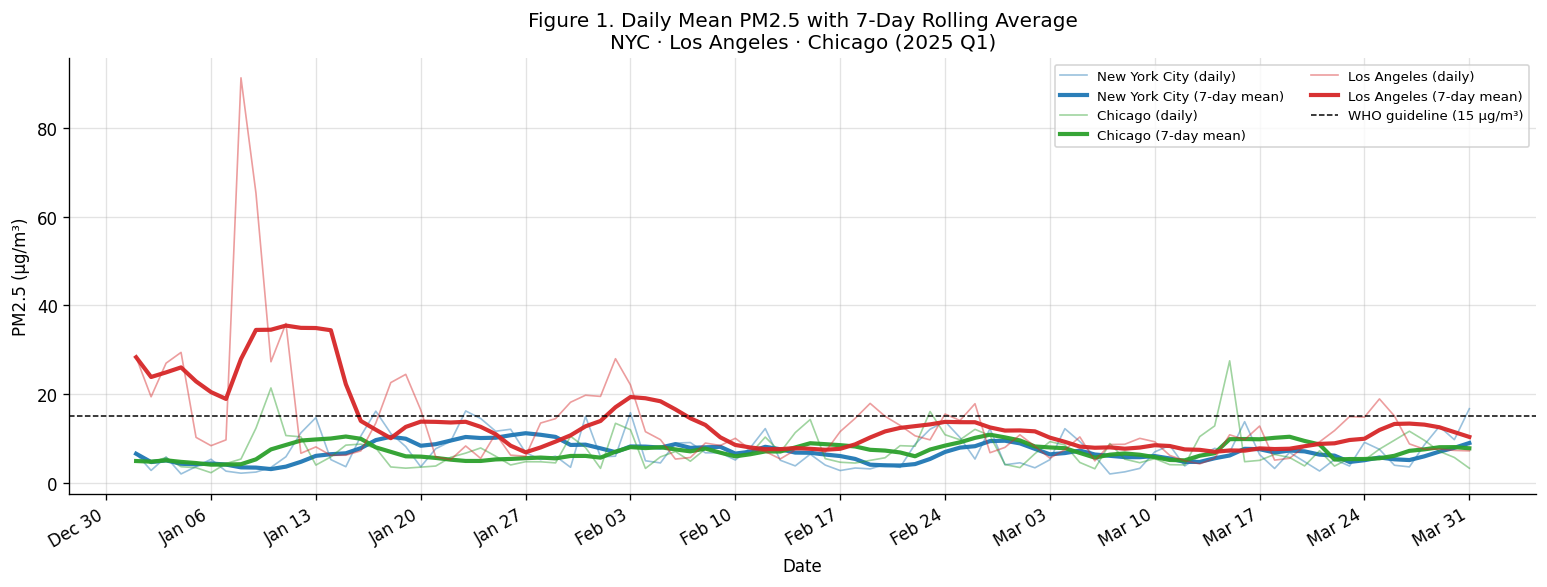

Figure saved to C:\Users\DCIT\Desktop\COMP6940 A1\part2_airquality\figures\fig1_timeseries_rolling7.png


In [17]:
fig, ax = plt.subplots(figsize=(13, 5))

for city in CITIES_ORDERED:
    sub = df_sorted[df_sorted['city'] == city].sort_values('date')
    color = PALETTE[city]
    # Daily series — thin, semi-transparent
    ax.plot(sub['date'], sub['pm25_mean'],
            color=color, linewidth=1.0, alpha=0.45, label=f'{city} (daily)')
    # Rolling 7-day mean — thick, opaque
    ax.plot(sub['date'], sub['pm25_rolling7'],
            color=color, linewidth=2.5, alpha=0.95, label=f'{city} (7-day mean)')

ax.axhline(15, color='black', linestyle='--', linewidth=0.9, label='WHO guideline (15 µg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_title('Figure 1. Daily Mean PM2.5 with 7-Day Rolling Average\nNYC · Los Angeles · Chicago (2025 Q1)',
             fontsize=12)
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('Date')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_timeseries_rolling7.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {FIG_DIR / "fig1_timeseries_rolling7.png"}')

## D2. Scatter Plot: `pm25_mean` vs `wind_speed_mean`, Separated by City

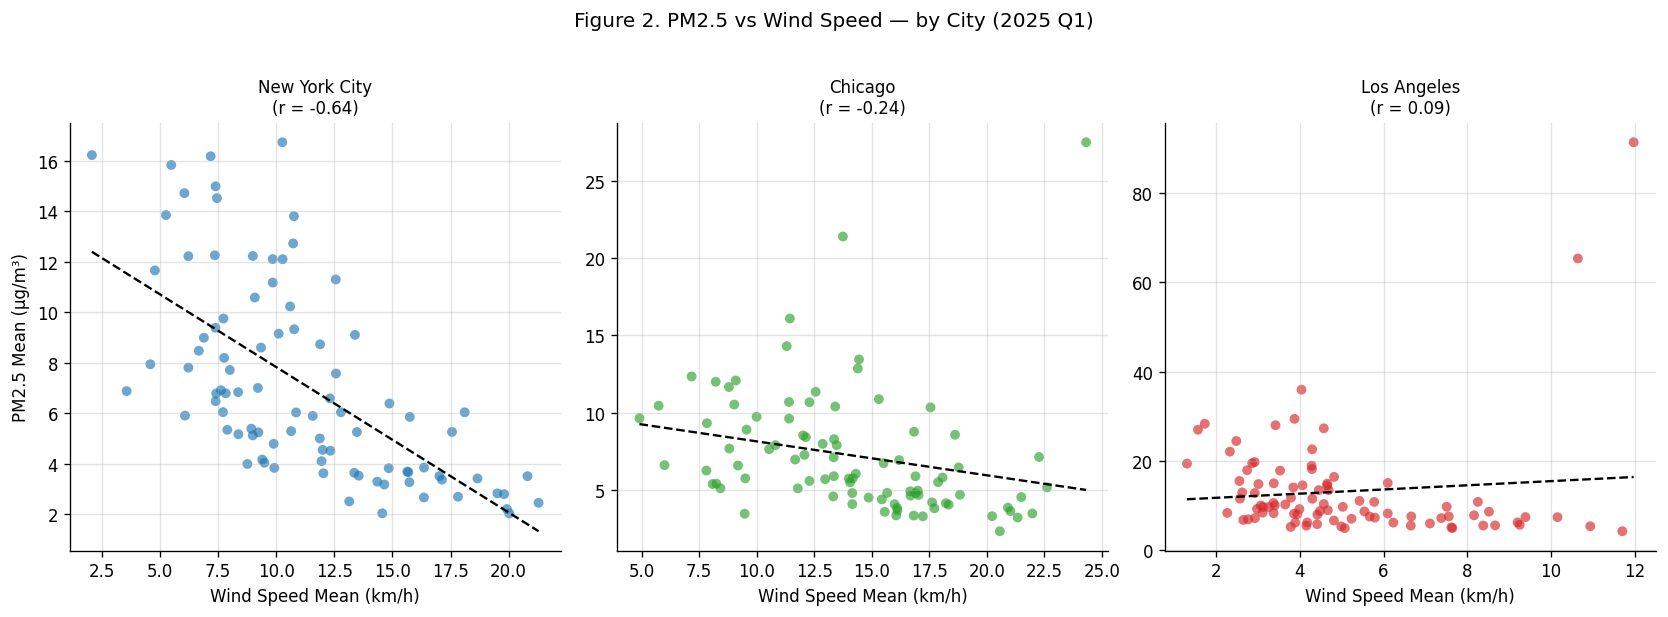

Figure saved to C:\Users\DCIT\Desktop\COMP6940 A1\part2_airquality\figures\fig2_scatter_pm25_wind.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)

for ax, city in zip(axes, CITIES_ORDERED):
    sub = df[df['city'] == city].copy()
    color = PALETTE[city]

    ax.scatter(sub['wind_speed_mean'], sub['pm25_mean'],
               color=color, alpha=0.65, s=35, edgecolors='none')

    # OLS trend line
    m, b = np.polyfit(sub['wind_speed_mean'], sub['pm25_mean'], 1)
    x_line = np.linspace(sub['wind_speed_mean'].min(), sub['wind_speed_mean'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.4, linestyle='--')

    r = sub[['wind_speed_mean', 'pm25_mean']].corr().iloc[0, 1]
    ax.set_title(f'{city}\n(r = {r:.2f})', fontsize=10)
    ax.set_xlabel('Wind Speed Mean (km/h)')
    ax.set_ylabel('PM2.5 Mean (µg/m³)' if city == 'New York City' else '')

fig.suptitle('Figure 2. PM2.5 vs Wind Speed — by City (2025 Q1)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_scatter_pm25_wind.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {FIG_DIR / "fig2_scatter_pm25_wind.png"}')

## D3. Distribution Comparison of `pm25_mean` Across Cities

Combined violin + strip plot for a complete picture of shape and individual observations.

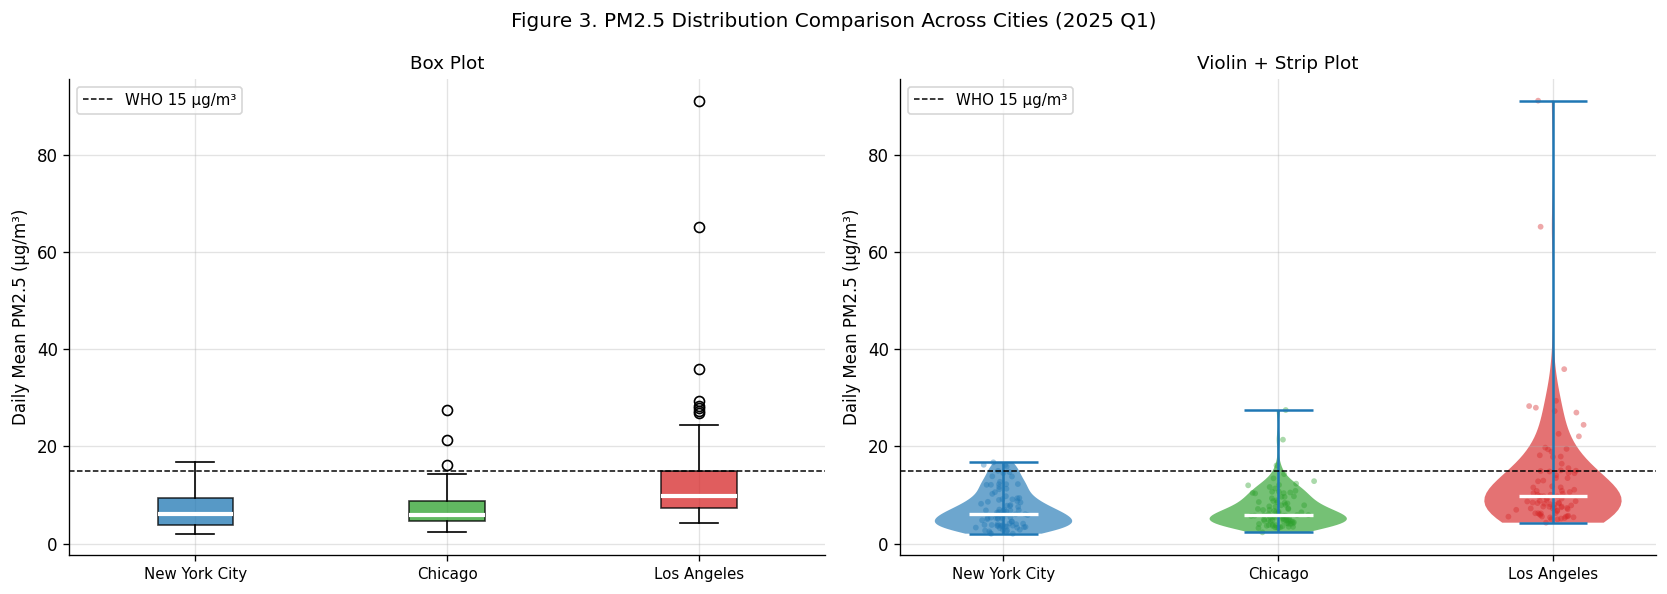

Figure saved to C:\Users\DCIT\Desktop\COMP6940 A1\part2_airquality\figures\fig3_distribution_comparison.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Box plot ---
ax = axes[0]
data_for_box = [df.loc[df['city'] == c, 'pm25_mean'].values for c in CITIES_ORDERED]
colors = [PALETTE[c] for c in CITIES_ORDERED]

bp = ax.boxplot(data_for_box, patch_artist=True, notch=False,
                medianprops={'color': 'white', 'linewidth': 2.5})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(range(1, 4))
ax.set_xticklabels(CITIES_ORDERED, fontsize=9)
ax.axhline(15, color='black', linestyle='--', linewidth=0.9, label='WHO 15 µg/m³')
ax.set_title('Box Plot', fontsize=11)
ax.set_ylabel('Daily Mean PM2.5 (µg/m³)')
ax.legend(fontsize=9)

# --- Right: Violin plot ---
ax2 = axes[1]
vp = ax2.violinplot(data_for_box, positions=[1, 2, 3], showmedians=True, showextrema=True)
for i, (body, color) in enumerate(zip(vp['bodies'], colors)):
    body.set_facecolor(color)
    body.set_alpha(0.65)
vp['cmedians'].set_color('white')
vp['cmedians'].set_linewidth(2)

# Overlay individual points
for i, (city, color) in enumerate(zip(CITIES_ORDERED, colors), 1):
    y = df.loc[df['city'] == city, 'pm25_mean'].values
    x = np.random.normal(i, 0.05, size=len(y))
    ax2.scatter(x, y, alpha=0.4, s=12, color=color, edgecolors='none')

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(CITIES_ORDERED, fontsize=9)
ax2.axhline(15, color='black', linestyle='--', linewidth=0.9, label='WHO 15 µg/m³')
ax2.set_title('Violin + Strip Plot', fontsize=11)
ax2.set_ylabel('Daily Mean PM2.5 (µg/m³)')
ax2.legend(fontsize=9)

fig.suptitle('Figure 3. PM2.5 Distribution Comparison Across Cities (2025 Q1)', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {FIG_DIR / "fig3_distribution_comparison.png"}')

## D4. Heatmap: PM2.5 Intensity — Cities over Time

A date × city heatmap showing `pm25_mean` intensity (colour-coded).  
Dates are on the y-axis; cities are on the x-axis.

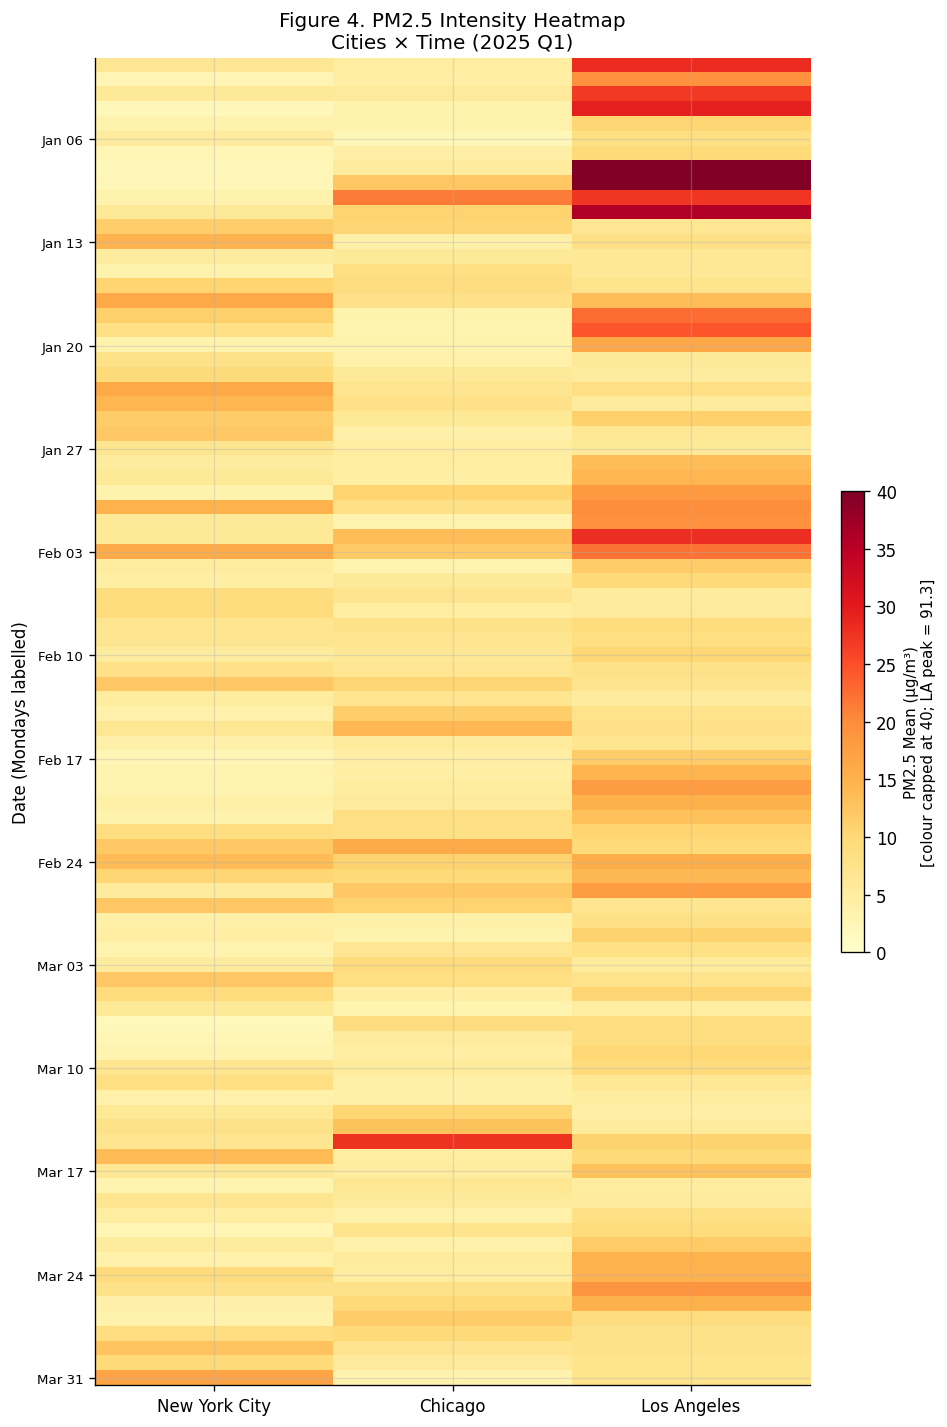

Figure saved to C:\Users\DCIT\Desktop\COMP6940 A1\part2_airquality\figures\fig4_heatmap_city_time.png


In [20]:
# Pivot: rows = date, columns = city, values = pm25_mean
pivot = (
    df.assign(date_str=df['date'].dt.strftime('%b %d'))
      .pivot_table(index='date', columns='city', values='pm25_mean')
      [CITIES_ORDERED]  # fix column order
      .sort_index()
)

# For display: use weekly ticks on y-axis to keep the chart readable
week_idx = [i for i, d in enumerate(pivot.index) if d.dayofweek == 0]  # Mondays
week_labels = [pivot.index[i].strftime('%b %d') for i in week_idx]

fig, ax = plt.subplots(figsize=(8, 12))

im = ax.imshow(
    pivot.values,
    aspect='auto',
    cmap='YlOrRd',
    interpolation='nearest',
    vmin=0,
    vmax=min(pivot.values.max(), 40)  # cap colour scale; LA outlier clipped
)

ax.set_xticks(range(len(CITIES_ORDERED)))
ax.set_xticklabels(CITIES_ORDERED, fontsize=10)
ax.set_yticks(week_idx)
ax.set_yticklabels(week_labels, fontsize=8)
ax.set_ylabel('Date (Mondays labelled)', fontsize=10)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('PM2.5 Mean (µg/m³)\n[colour capped at 40; LA peak = 91.3]', fontsize=9)

# WHO guideline annotation
ax.set_title(
    'Figure 4. PM2.5 Intensity Heatmap\nCities × Time (2025 Q1)',
    fontsize=12
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_heatmap_city_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved to {FIG_DIR / "fig4_heatmap_city_time.png"}')

---
# Key Findings Summary

In [21]:
q_final = """
SELECT
    city,
    ROUND(AVG(pm25_mean),    2) AS mean_pm25,
    ROUND(MEDIAN(pm25_mean), 2) AS median_pm25,
    ROUND(STDDEV(pm25_mean), 2) AS std_pm25,
    ROUND(MAX(pm25_mean),    2) AS peak_pm25,
    SUM(CASE WHEN pm25_mean > 15 THEN 1 ELSE 0 END) AS days_above_who,
    ROUND(CORR(pm25_mean, temp_mean),       3) AS r_temp,
    ROUND(CORR(pm25_mean, wind_speed_mean), 3) AS r_wind,
    ROUND(CORR(pm25_mean, precip_sum),      3) AS r_precip,
    ROUND(
        AVG(CASE WHEN is_weekend = 1 THEN pm25_mean END)
        - AVG(CASE WHEN is_weekend = 0 THEN pm25_mean END),
    2) AS weekend_vs_weekday_delta
FROM aq
GROUP BY city
ORDER BY mean_pm25 DESC
"""
print('=== Combined Summary Table (DuckDB) ===')
con.execute(q_final).df()

=== Combined Summary Table (DuckDB) ===


,city,mean_pm25,median_pm25,std_pm25,peak_pm25,days_above_who,r_temp,r_wind,r_precip,weekend_vs_weekday_delta
0,Los Angeles,13.17,9.71,12.03,91.26,22.0,0.175,0.093,-0.195,0.24
1,Chicago,7.21,5.87,3.99,27.51,3.0,0.183,-0.237,0.043,0.42
2,New York City,7.12,6.04,3.91,16.73,4.0,0.040,-0.638,-0.057,0.20
